# PageRank Project - Ranking similarity between papers
### **Student: Aleksandra Zografska (48924A)**
### **Subject: Algorithms for Massive Datasets**


#### 0. Prep environment
- Download Spark
- Align cloudpickle version that caused errors
- Import Spark into notebook

In [1]:
!apt-get update -qq
!apt-get install openjdk-8-jdk-headless
!wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz
!tar xf spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.1.1-bin-hadoop3.2"

!pip install cloudpickle==2.2.0

import cloudpickle, shutil, os

new_cp_path = os.path.dirname(cloudpickle.__file__)
pyspark_cp_path = "/content/spark-3.1.1-bin-hadoop3.2/python/pyspark/cloudpickle"

print("Replacing:", pyspark_cp_path)
print("With:", new_cp_path)

shutil.copytree(new_cp_path, pyspark_cp_path, dirs_exist_ok=True)

print("Done!")

import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better

sc = spark.sparkContext

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-8-jdk-headless is already the newest version (8u482-ga~us1-0ubuntu1~22.04).
0 upgraded, 0 newly installed, 0 to remove and 104 not upgraded.
Replacing: /content/spark-3.1.1-bin-hadoop3.2/python/pyspark/cloudpickle
With: /usr/local/lib/python3.12/dist-packages/cloudpickle
Done!



#### 1. Download and Load Dataset into memory
Using https://www.kaggle.com/datasets/Cornell-University/arxiv

In [2]:
import os
os.environ['KAGGLE_USERNAME'] = "aleksandrazografska"
os.environ['KAGGLE_KEY'] = "KGAT_190e0a2b50e5230eee516795d4851ce5"
!kaggle datasets download -d Cornell-University/arxiv


Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
arxiv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
import zipfile

with zipfile.ZipFile("arxiv.zip", "r") as zip_ref:
    zip_ref.extractall("arxiv_data")

A regular json read didn't suffice. Session crached because of using too much ram, we need to load it by chunks.





In [4]:
import pandas as pd
chunks = pd.read_json(
    "arxiv_data/arxiv-metadata-oai-snapshot.json",
    lines=True,
    chunksize=10000
)

for chunk in chunks:
    print(chunk.head())
    break  # remove break to process full dataset

         id           submitter  \
0  704.0001      Pavel Nadolsky   
1  704.0002        Louis Theran   
2  704.0003         Hongjun Pan   
3  704.0004        David Callan   
4  704.0005  Alberto Torchinsky   

                                             authors  \
0  C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...   
1                    Ileana Streinu and Louis Theran   
2                                        Hongjun Pan   
3                                       David Callan   
4           Wael Abu-Shammala and Alberto Torchinsky   

                                               title  \
0  Calculation of prompt diphoton production cros...   
1           Sparsity-certifying Graph Decompositions   
2  The evolution of the Earth-Moon system based o...   
3  A determinant of Stirling cycle numbers counts...   
4  From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...   

                                  comments  \
0  37 pages, 15 figures; published version   
1    To appear in Graph

In [5]:
''' As we will often print probability values,
we will modify the default setting of numpy so that
float entries in arrays are printed showing only a few decimal digits.'''
import numpy as np
np.set_printoptions(precision=3)


Helper functions for creating graph, getting the connection matrix and calculating a simple page rank.

In [6]:
def l2distance(v, q):
    '''Computes the Euclidean distance between two vectors.

    Args

    v: list or tuple
    q: list or tuple

    Returns

    d: Euclidean distance between v and q

    Throws exception of v and q do not have the same length.
    '''

    if len(v) != len(q):
        raise ValueError('Cannot compute the distance'
                         ' of two vectors of different size')

    return sum([(q_el - v_el)**2 for v_el, q_el in zip(v, q)])

def get_graph(pages, links):
    g = nx.DiGraph()

    for p in pages:
        g.add_node(p)

    for (a, b) in links:
        g.add_edge(pages[a], pages[b])

    return g

def get_connection_matrix(pages, links):
    incidency = {}
    for u in range(len(pages)):
        incidency[u] = []

    for (a, b) in links:
        incidency[a].append(b)

    connection_matrix = []
    for a in incidency:
       for b in incidency[a]:
            connection_matrix.append((b, a, 1./len(incidency[a])))

    return connection_matrix

def get_page_rank(pages, links,
                  verbose=False, tolerance=10e-7, max_iterations=100):
    print("start")
    connection_matrix = get_connection_matrix(pages, links)
    print("connection matrix obtained")
    links_RDD = sc.parallelize(connection_matrix).cache()
    print("RDD created")


    n = len(pages)
    all_nodes_RDD = sc.parallelize([(i, 0.0) for i in range(n)]).cache()
    page_rank = np.ones(n)/n
    old_page_rank = np.ones(n)

    iteration = 0
    d = 0.85
    dist = l2distance(old_page_rank, page_rank)
    print(f"distance {dist}")
    print("start loop")
    while dist >= tolerance and \
          iteration < max_iterations:
        old_page_rank = page_rank
        print("before collect")
        page_rank_values = (links_RDD
                            .map(lambda t: (t[0], t[2]*page_rank[t[1]]))
                            .union(all_nodes_RDD)
                            .reduceByKey(lambda a, b: a+b)
                            .sortByKey()
                            .collect()
                           )
        print("after collect")
        page_rank = np.array([c for (i, c) in page_rank_values])
        page_rank = d * page_rank + (1 - d) / n  # teleportation
        print("after page rank calculation")
        if verbose:
            print(page_rank, dist)

        iteration += 1
        dist = l2distance(old_page_rank, page_rank)

    print('{} iterations'.format(iteration))

    return page_rank

#### Page Rank: The author that collaborates the most with other authors

In [7]:
from itertools import combinations

# Filter to one category to keep it manageable
CATEGORY = "cs.LG"

page_index = {}  # name -> int index
links_set = set()  # (int, int) tuples — much smaller

for chunk in pd.read_json("arxiv_data/arxiv-metadata-oai-snapshot.json", lines=True, chunksize=10000):
    chunk = chunk[chunk["categories"].str.contains(CATEGORY, na=False)]  # filter early

    for authors in chunk["authors_parsed"]:
        names = [f"{a[1]} {a[0]}".strip() for a in authors if a[0] or a[1]]

        # Assign integer index on first sight
        for name in names:
            if name not in page_index:
                page_index[name] = len(page_index)

        # Store int pairs, not string pairs
        ids = [page_index[n] for n in names]
        for a, b in combinations(ids, 2):
            links_set.add((a, b))
            links_set.add((b, a))

pages = list(page_index.keys())
links = list(links_set)

print(f"{len(pages)} authors, {len(links)} links")

341387 authors, 8353154 links


In [8]:
rank = get_page_rank(pages, links, verbose=True)
# See top authors
ranked = sorted(zip(pages, rank), key=lambda x: -x[1])
for author, score in ranked[:20]:
    print(f"{score:.6f}  {author}")

start
connection matrix obtained
RDD created
distance 341385.0000032844
start loop
before collect
after collect
after page rank calculation
[1.215e-05 1.536e-05 2.780e-06 ... 9.729e-07 7.160e-07 6.270e-07] 341385.0000032844
before collect
after collect
after page rank calculation
[1.001e-05 1.041e-05 2.664e-06 ... 1.264e-06 1.074e-06 9.054e-07] 4.421812233717713e-06
2 iterations
0.000273  Yang Liu
0.000196  Wei Wang
0.000177  Hao Wang
0.000159  Bo Li
0.000146  Yang Li
0.000146  Yoshua Bengio
0.000144  Xiang Li
0.000138  Yu Zhang
0.000138  Yang Yang
0.000135  Jun Wang
0.000132  Yu Wang
0.000131  Wei Zhang
0.000130  Xin Wang
0.000127  Xi Chen
0.000124  Hao Chen
0.000122  Wei Chen
0.000113  Rui Wang
0.000112  Chang Liu
0.000109  Wei Liu
0.000106  Xin Liu


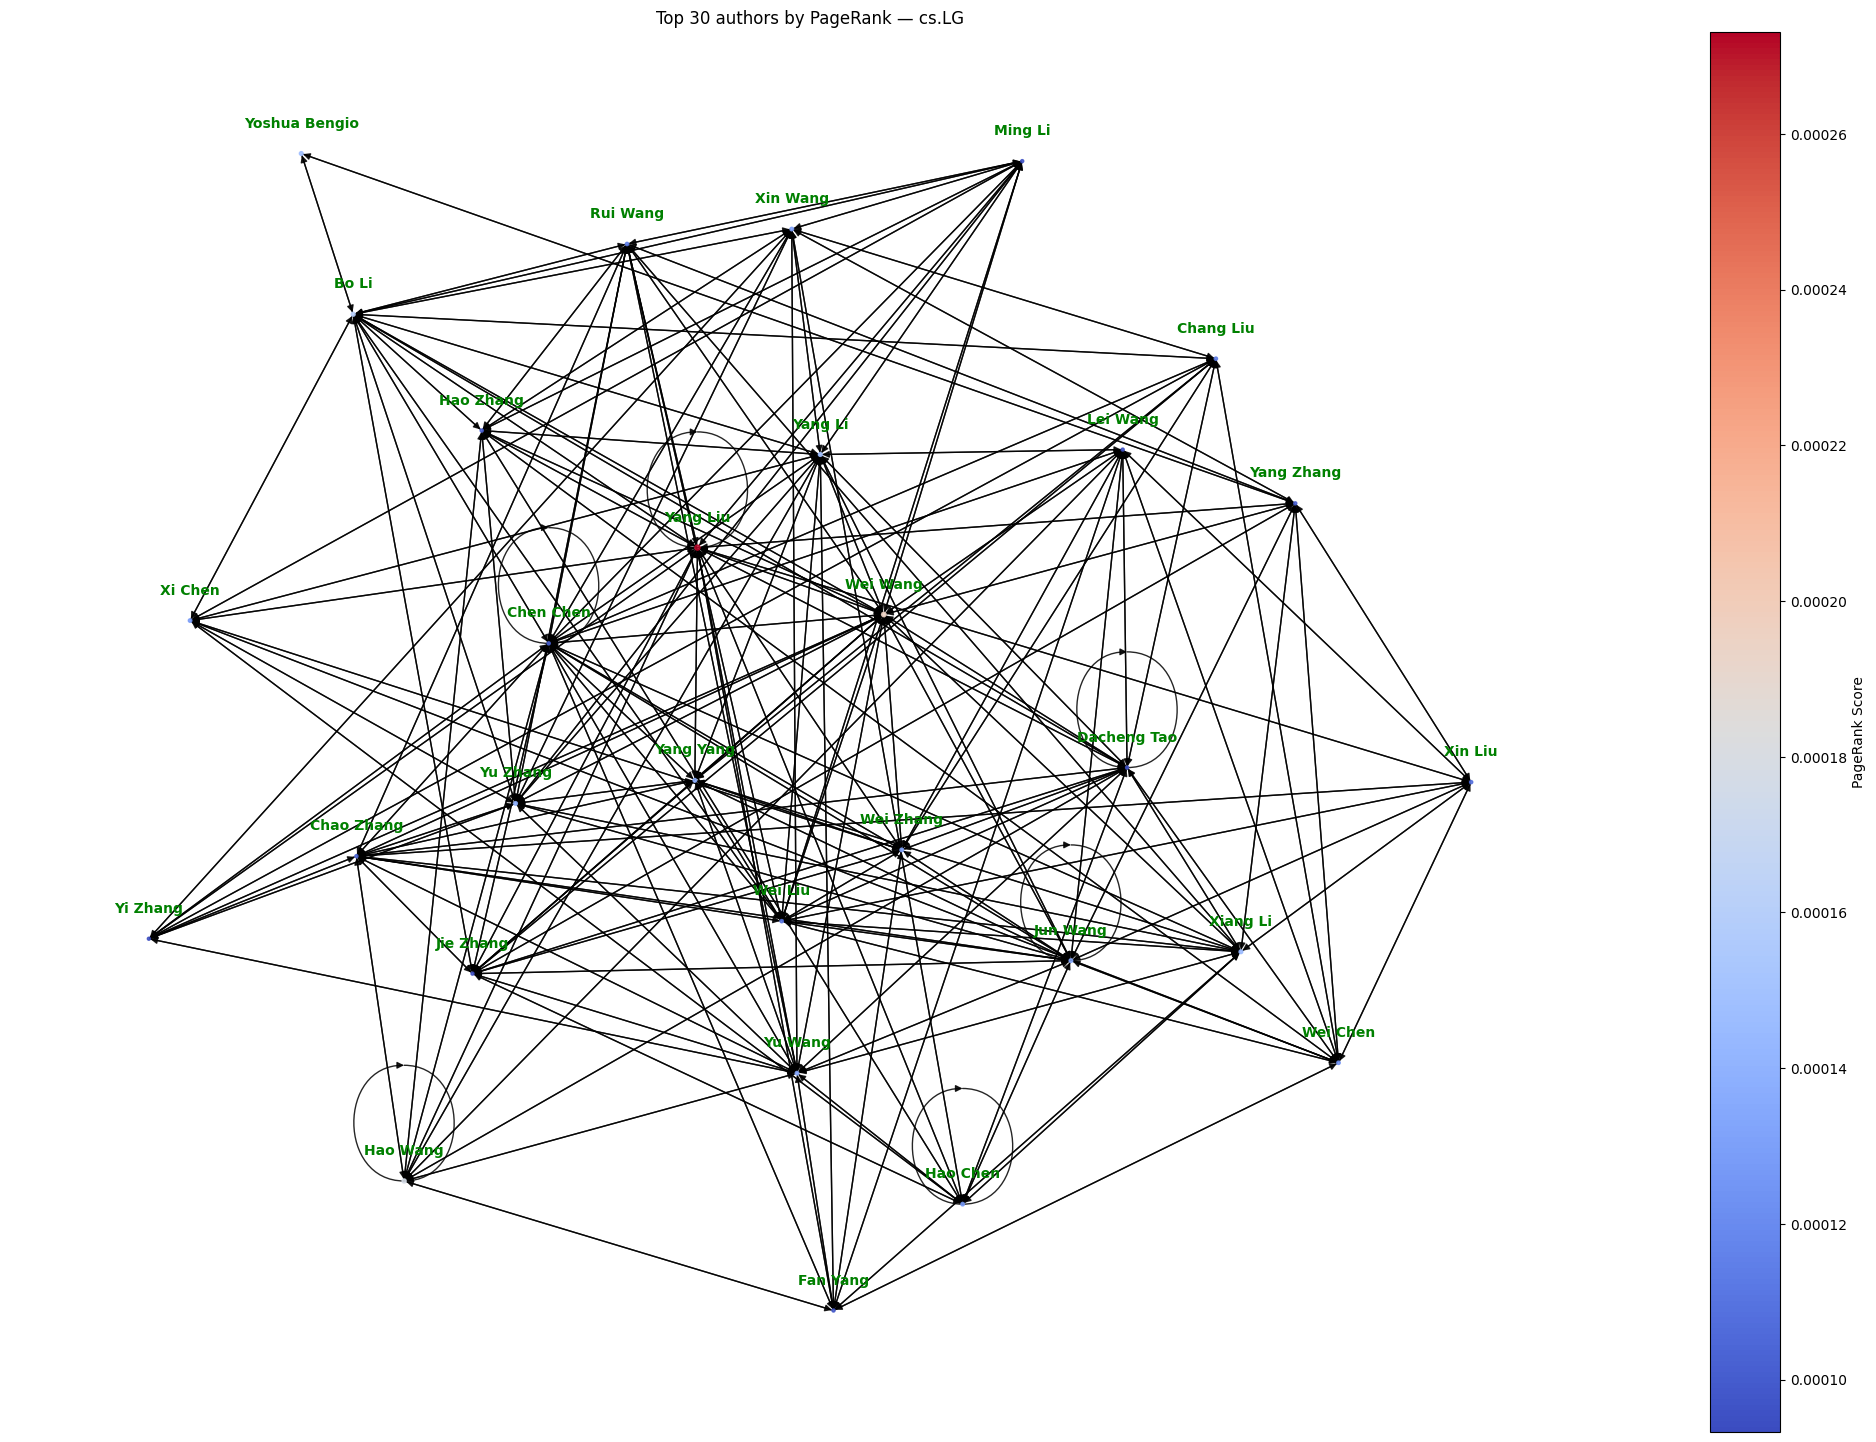

In [18]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Take top N authors by rank
top_n = 30
ranked = sorted(zip(pages, rank), key=lambda x: -x[1])
top_authors = [author for author, _ in ranked[:top_n]]
top_scores = {author: score for author, score in ranked[:top_n]}

# Build subgraph
top_set = set(top_authors)
top_page_index = {name: i for i, name in enumerate(top_authors)}

top_links = [(top_page_index[pages[a]], top_page_index[pages[b]])
             for a, b in links
             if pages[a] in top_set and pages[b] in top_set]

g = get_graph(top_authors, top_links)

pos = nx.spring_layout(g, seed=42, k=2)  # k controls spacing
node_colors = [top_scores[author] for author in g.nodes()]
node_sizes  = [top_scores[author] * 50000 for author in g.nodes()]
page_labels = {author: author for author in g.nodes()}

# Plot
plt.figure(figsize=(20, 14))
# nx.draw(g, with_labels=True, labels=page_labels, pos=pos,
#         node_color=node_colors, cmap=plt.cm.coolwarm,
#         node_size=node_sizes, font_size=14, alpha=0.85)
nx.draw(g, pos=pos, node_color=node_colors, cmap=plt.cm.coolwarm,
        node_size=node_sizes, alpha=0.85, with_labels=False)

# Draw labels with a vertical offset so they sit above the nodes
offset_pos = {node: (x, y + 0.05) for node, (x, y) in pos.items()}
nx.draw_networkx_labels(g, offset_pos, labels=page_labels, font_size=10, font_color="green", font_weight="bold")

sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm,
     norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
plt.colorbar(sm, ax=plt.gca(), label="PageRank Score") # passing ax=plt.gca() to give the colorbar an axes to attatch to
plt.title(f"Top {top_n} authors by PageRank — {CATEGORY}")
plt.show()

#### Visualize Simple Rank